# IF3270 Pembelajaran Mesin — Tugas Besar 1
## FFNN From Scratch: Global Student Placement & Salary


## 1. Import Required Libraries

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from utils import (
    run_architecture_experiments,
    run_learning_rate_experiments,
    plot_train_val_curves,
    plot_prediction_bars,
    analyze_results_distributions,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)

## 2. Load and Explore the Dataset

In [2]:
DATA_PATH = '../data/student_placement_salary.csv'

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.describe()

cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
dtype: object

Missing values:
 cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64


,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [4]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)


college_tier:
college_tier
Tier 2    3993
Tier 1    3034
Tier 3    2973
Name: count, dtype: int64
----------------------------------------

country:
country
Germany    2057
USA        2040
India      1985
Canada     1976
UK         1942
Name: count, dtype: int64
----------------------------------------

university_ranking_band:
university_ranking_band
300+       4075
100-300    3975
Top 100    1950
Name: count, dtype: int64
----------------------------------------

specialization:
specialization
Data Science     2036
Core CS          2007
Cybersecurity    1992
AI/ML            1991
Cloud            1974
Name: count, dtype: int64
----------------------------------------

industry:
industry
Consulting       1739
Healthcare       1680
Manufacturing    1673
Tech             1643
Finance          1635
Other            1630
Name: count, dtype: int64
----------------------------------------

placement_status:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
--

/var/folders/8s/llh9c9bx2ml34sgvxbtf2lsr0000gn/T/ipykernel_17783/3917929229.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


## 3. Data Preprocessing

In [5]:
TARGET_COL  = 'placement_status'   

df = df.dropna(subset=[TARGET_COL])

# 2. Encode categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]

label_cols = ['college_tier', 'university_ranking_band']
ohe_cols = [o for o in cat_cols if o not in label_cols]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

# 3. Encode target
y_raw = le.fit_transform(df[TARGET_COL].astype(str))
n_classes = len(np.unique(y_raw))

if n_classes == 2:
    # Binary classification → sigmoid + BCE
    y = y_raw.reshape(-1, 1).astype(float)
    TASK = 'binary'
else:
    # Multi-class → softmax + CCE (one-hot)
    y = np.eye(n_classes)[y_raw]
    TASK = 'multiclass'

print(f"Task: {TASK}, classes: {n_classes}, y shape: {y.shape}")

# 4. Feature matrix
X_df = df.drop(columns=[TARGET_COL])
X_df = X_df.select_dtypes(include=[np.number]).fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values).astype(float)
print(f"X shape: {X.shape}")

# 5. Train / validation / test split  (60 / 20 / 20)
X_tmp,  X_test,  y_tmp,  y_test  = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Task: binary, classes: 2, y shape: (10000, 1)
X shape: (10000, 8)
Train: (6000, 8), Val: (2000, 8), Test: (2000, 8)


/var/folders/8s/llh9c9bx2ml34sgvxbtf2lsr0000gn/T/ipykernel_17783/903252314.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## 4. Model Testing


### 4.1 Hyperparameter

#### 4.1.1 Depth and Width Parameter

In [6]:
n_features = X_train.shape[1]
n_out      = y_train.shape[1]

experiments = {
    # Width Variations (depth = 2 tetap)
    'Width_Small': [
        {'n_in': n_features,  'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': 16, 'activation': 'relu'},
        {'n_in': 16, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Medium': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Large': [
        {'n_in': n_features,   'n_out': 128, 'activation': 'relu'},
        {'n_in': 128, 'n_out': 64,  'activation': 'relu'},
        {'n_in': 64,  'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    
    # Depth Variations (width = 64 tetap)
    'Depth_1': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_2': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_3': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
}


In [7]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

results = run_architecture_experiments(
    experiments=experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Width_Small
  Layer 1: DenseLayer(8 → 32, activation=ReLU)  [288 params]
  Layer 2: DenseLayer(32 → 16, activation=ReLU)  [528 params]
  Layer 3: DenseLayer(16 → 1, activation=Sigmoid)  [17 params]
----------------------------------------------------
  Total params: 833
Epoch 10/200, Train Loss: 0.5406, Val Loss: 0.5316
Epoch 20/200, Train Loss: 0.5076, Val Loss: 0.5030
Epoch 30/200, Train Loss: 0.5008, Val Loss: 0.4979
Epoch 40/200, Train Loss: 0.4959, Val Loss: 0.4950
Epoch 50/200, Train Loss: 0.4937, Val Loss: 0.4944
Epoch 60/200, Train Loss: 0.4933, Val Loss: 0.4950
Epoch 70/200, Train Loss: 0.4917, Val Loss: 0.4952
Epoch 80/200, Train Loss: 0.4916, Val Loss: 0.4966
Epoch 90/200, Train Loss: 0.4901, Val Loss: 0.4966
Epoch 100/200, Train Loss: 0.4900, Val Loss: 0.4975
Epoch 110/200, Train Loss: 0.4898, Val Loss: 0.4980
Epoch 120/200, Train Loss: 0.4894, Val Loss: 0.4976
Epoch 130/200, Train Loss: 0.4890, Val Loss: 0.4993
Epoch 140/200, Train Loss: 0.4886, Val Loss: 0.5007


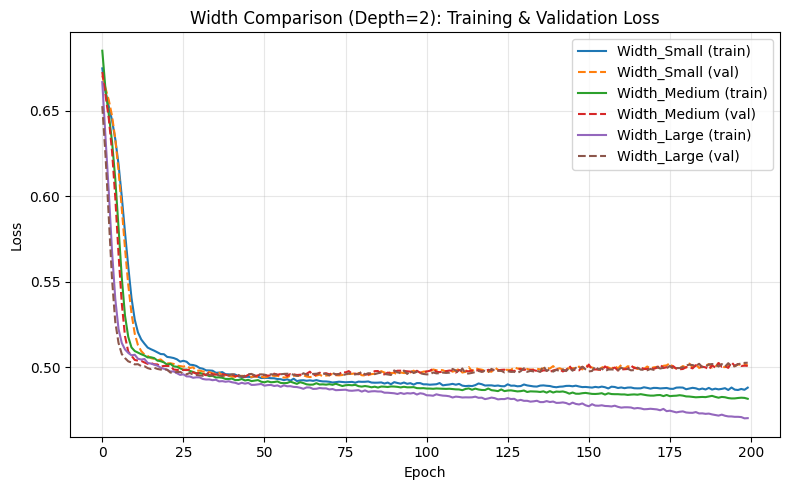

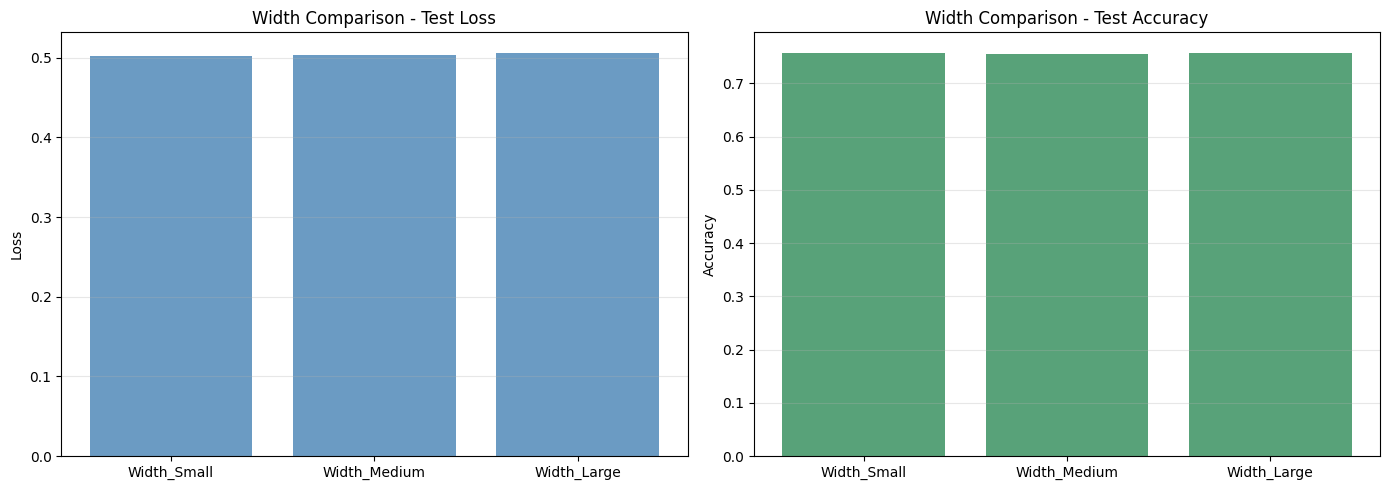

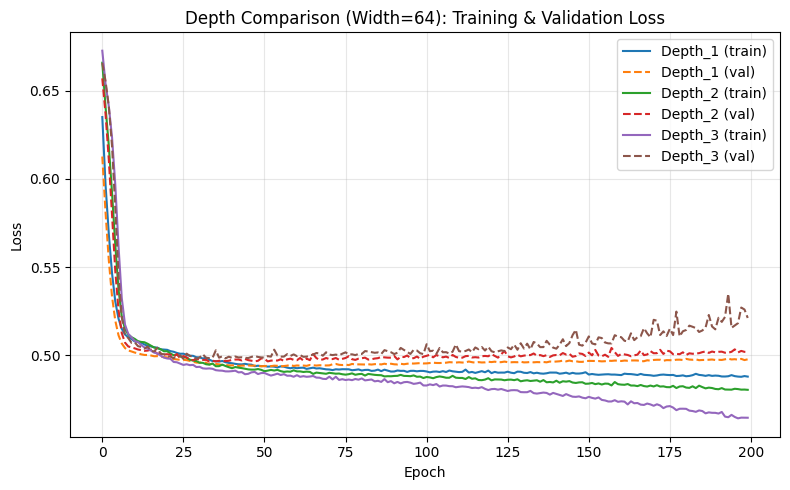

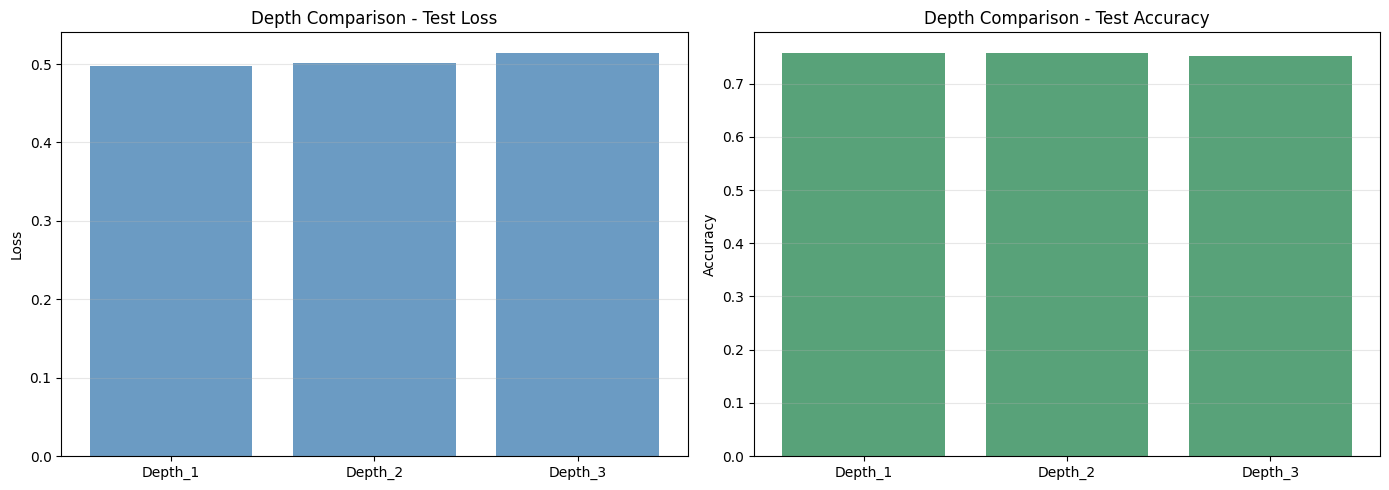

In [8]:
width_results = {k: results[k] for k in ['Width_Small', 'Width_Medium', 'Width_Large']}
depth_results = {k: results[k] for k in ['Depth_1', 'Depth_2', 'Depth_3']}

plot_train_val_curves(
    width_results,
    title='Width Comparison (Depth=2): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    width_results,
    title_prefix='Width Comparison',
)

plot_train_val_curves(
    depth_results,
    title='Depth Comparison (Width=64): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    depth_results,
    title_prefix='Depth Comparison',
)

### 4.1.2 Fungsi Aktivasi

In [9]:
BASE_ARCH = [128, 64]

activation_functions = ['linear', 'relu', 'sigmoid', 'tanh']

activation_experiments = {}

for act_name in activation_functions:
    config = []
    
    # Hidden Layer 1
    config.append({
        'n_in': n_features,
        'n_out': BASE_ARCH[0],
        'activation': act_name
    })
    
    # Hidden Layer 2
    config.append({
        'n_in': BASE_ARCH[0],
        'n_out': BASE_ARCH[1],
        'activation': act_name 
    })
    
    # Output Layer
    config.append({
        'n_in': BASE_ARCH[1],
        'n_out': n_out,
        'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'
    })
    
    activation_experiments[f'Act_{act_name.capitalize()}'] = config

print("Activation Function Experiments:")
for name, config in activation_experiments.items():
    hidden_act = config[0]['activation']
    print(f"  {name}: Hidden layers use '{hidden_act}' activation")

Activation Function Experiments:
  Act_Linear: Hidden layers use 'linear' activation
  Act_Relu: Hidden layers use 'relu' activation
  Act_Sigmoid: Hidden layers use 'sigmoid' activation
  Act_Tanh: Hidden layers use 'tanh' activation


In [10]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

activation_results = run_architecture_experiments(
    experiments=activation_experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Act_Linear
  Layer 1: DenseLayer(8 → 128, activation=Linear)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=Linear)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5117, Val Loss: 0.5020
Epoch 20/200, Train Loss: 0.5119, Val Loss: 0.5026
Epoch 30/200, Train Loss: 0.5121, Val Loss: 0.5030
Epoch 40/200, Train Loss: 0.5123, Val Loss: 0.5026
Epoch 50/200, Train Loss: 0.5118, Val Loss: 0.5032
Epoch 60/200, Train Loss: 0.5118, Val Loss: 0.5025
Epoch 70/200, Train Loss: 0.5116, Val Loss: 0.5025
Epoch 80/200, Train Loss: 0.5121, Val Loss: 0.5028
Epoch 90/200, Train Loss: 0.5118, Val Loss: 0.5025
Epoch 100/200, Train Loss: 0.5114, Val Loss: 0.5029
Epoch 110/200, Train Loss: 0.5122, Val Loss: 0.5022
Epoch 120/200, Train Loss: 0.5120, Val Loss: 0.5026
Epoch 130/200, Train Loss: 0.5121, Val Loss: 0.5025
Epoch 140/200, Train Loss: 0.5118, Val Lo

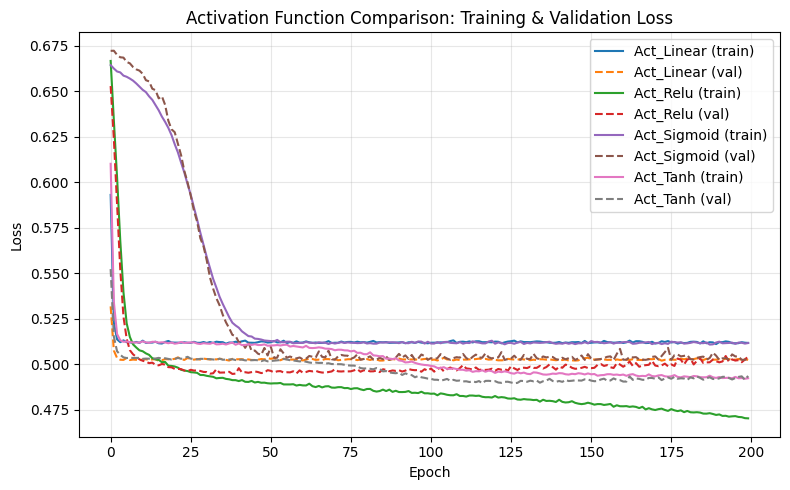

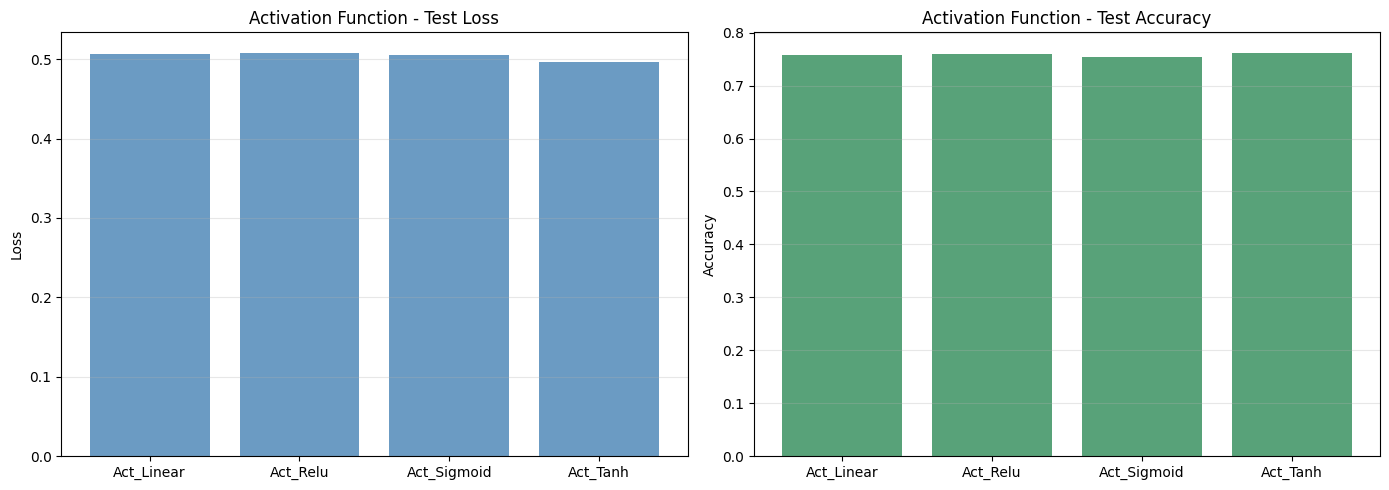

In [11]:
plot_train_val_curves(
    activation_results,
    title='Activation Function Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    activation_results,
    title_prefix='Activation Function',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Linear
Test Accuracy: 0.7570

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.004006 | Std: 0.100138
  Min: -0.359583 | Max: 0.325654
  Median: -0.001726

Layer 1:
  Shape: (128, 64)
  Mean: -0.000755 | Std: 0.100452
  Min: -0.442601 | Max: 0.405847
  Median: -0.000585

Layer 2:
  Shape: (64, 1)
  Mean: 0.001092 | Std: 0.100254
  Min: -0.228312 | Max: 0.243148
  Median: 0.001352

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000230 | Std: 0.009935
  Min: -0.050246 | Max: 0.058995
  Median: 0.000196
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

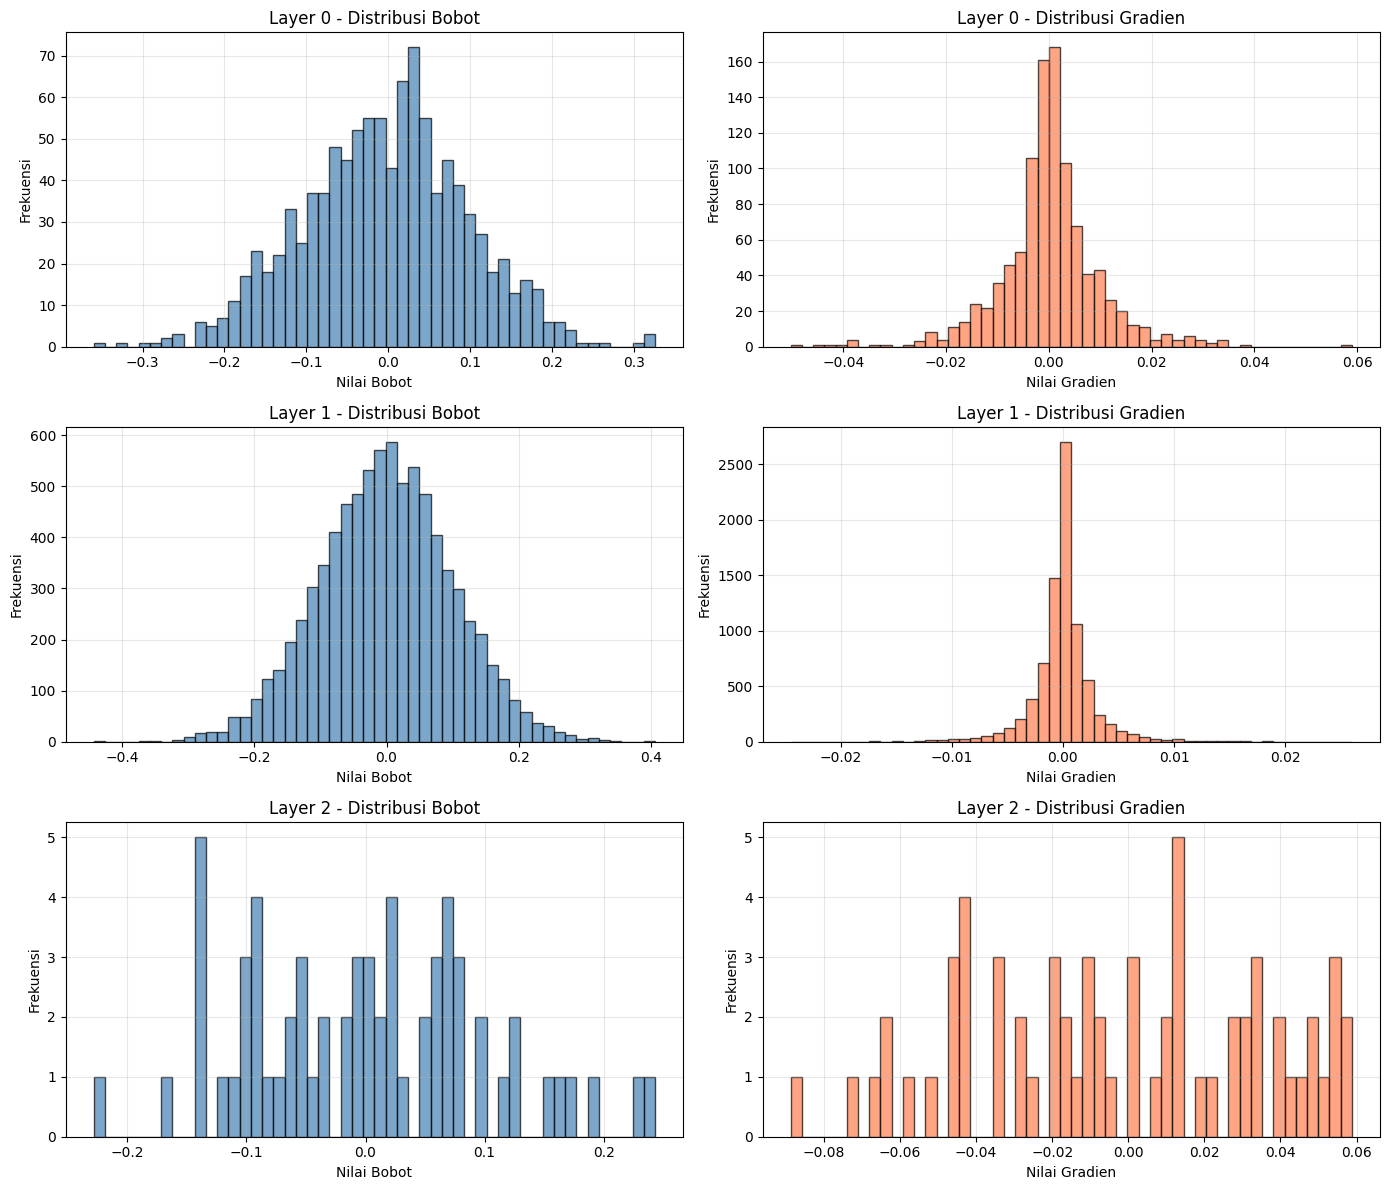


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Relu
Test Accuracy: 0.7605

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001987 | Std: 0.125477
  Min: -0.406672 | Max: 0.550352
  Median: 0.001165

Layer 1:
  Shape: (128, 64)
  Mean: 0.001595 | Std: 0.103969
  Min: -0.438692 | Max: 0.421103
  Median: 0.001862

Layer 2:
  Shape: (64, 1)
  Mean: 0.033405 | Std: 0.310535
  Min: -0.625678 | Max: 0.709320
  Median: 0.036529

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000402 | Std: 0.030659
  Min: -0.136569 | Max: 0.120457
  Median: 0.000419
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128, 

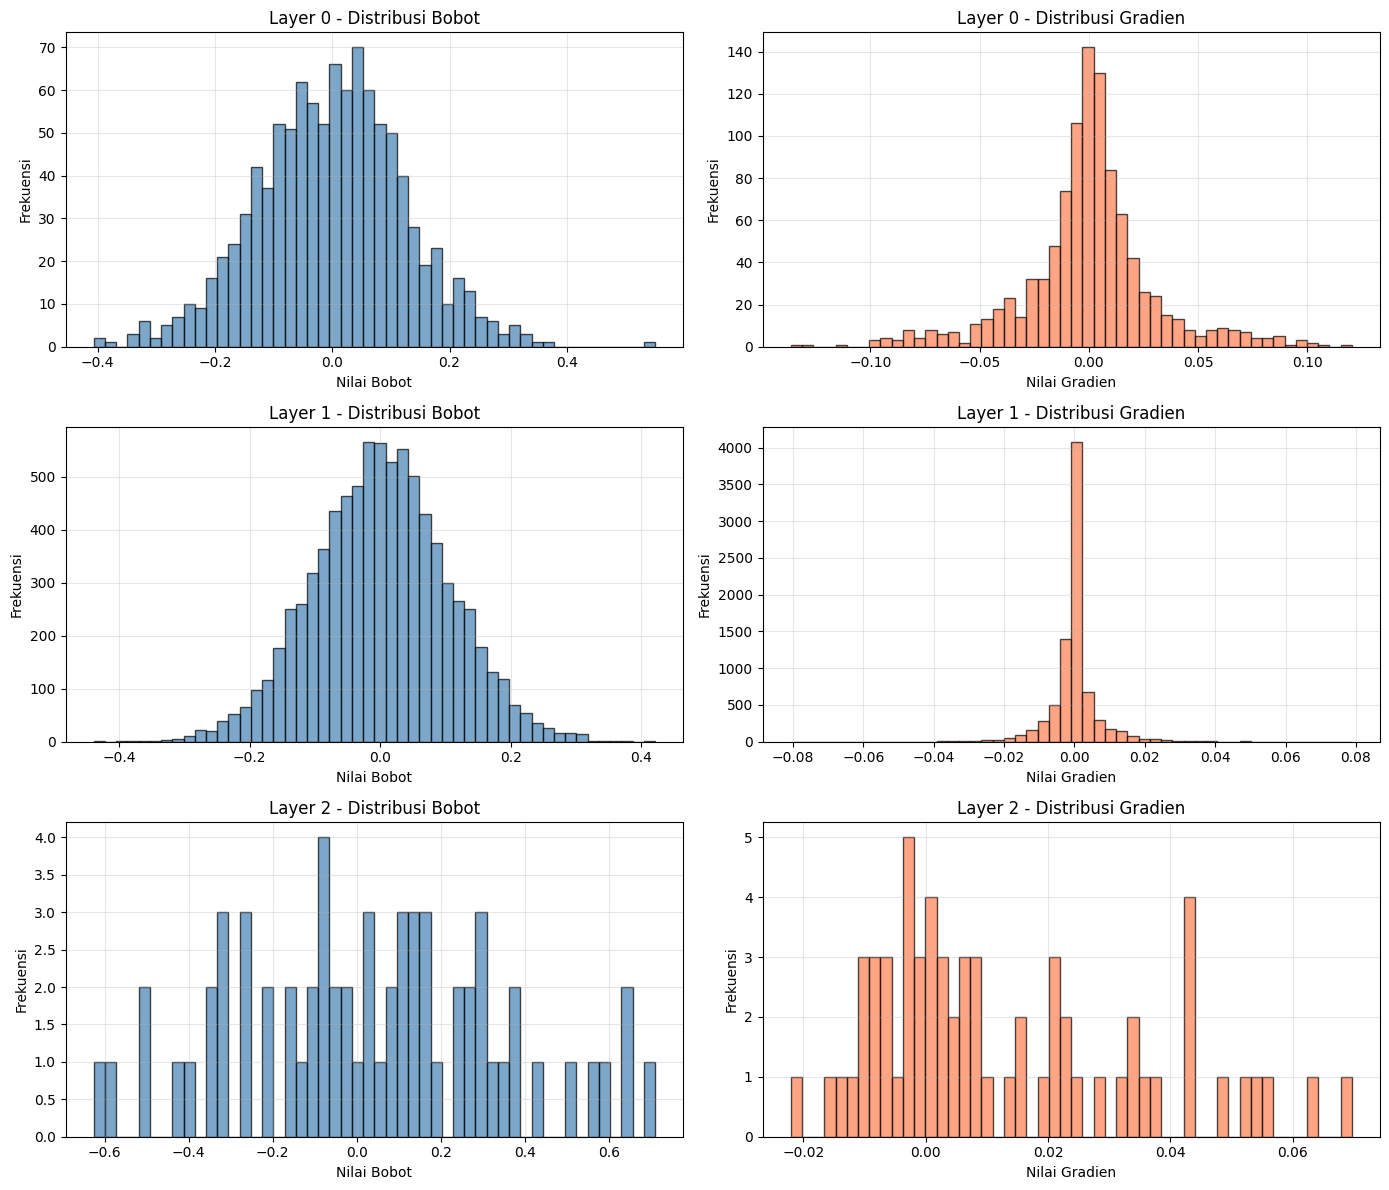


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Sigmoid
Test Accuracy: 0.7535

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.003485 | Std: 0.126167
  Min: -0.432703 | Max: 0.500553
  Median: 0.000217

Layer 1:
  Shape: (128, 64)
  Mean: -0.000793 | Std: 0.104335
  Min: -0.443518 | Max: 0.447812
  Median: -0.000724

Layer 2:
  Shape: (64, 1)
  Mean: 0.013289 | Std: 0.337741
  Min: -0.537669 | Max: 0.858775
  Median: 0.020400

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000003 | Std: 0.002016
  Min: -0.010629 | Max: 0.011047
  Median: 0.000003
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

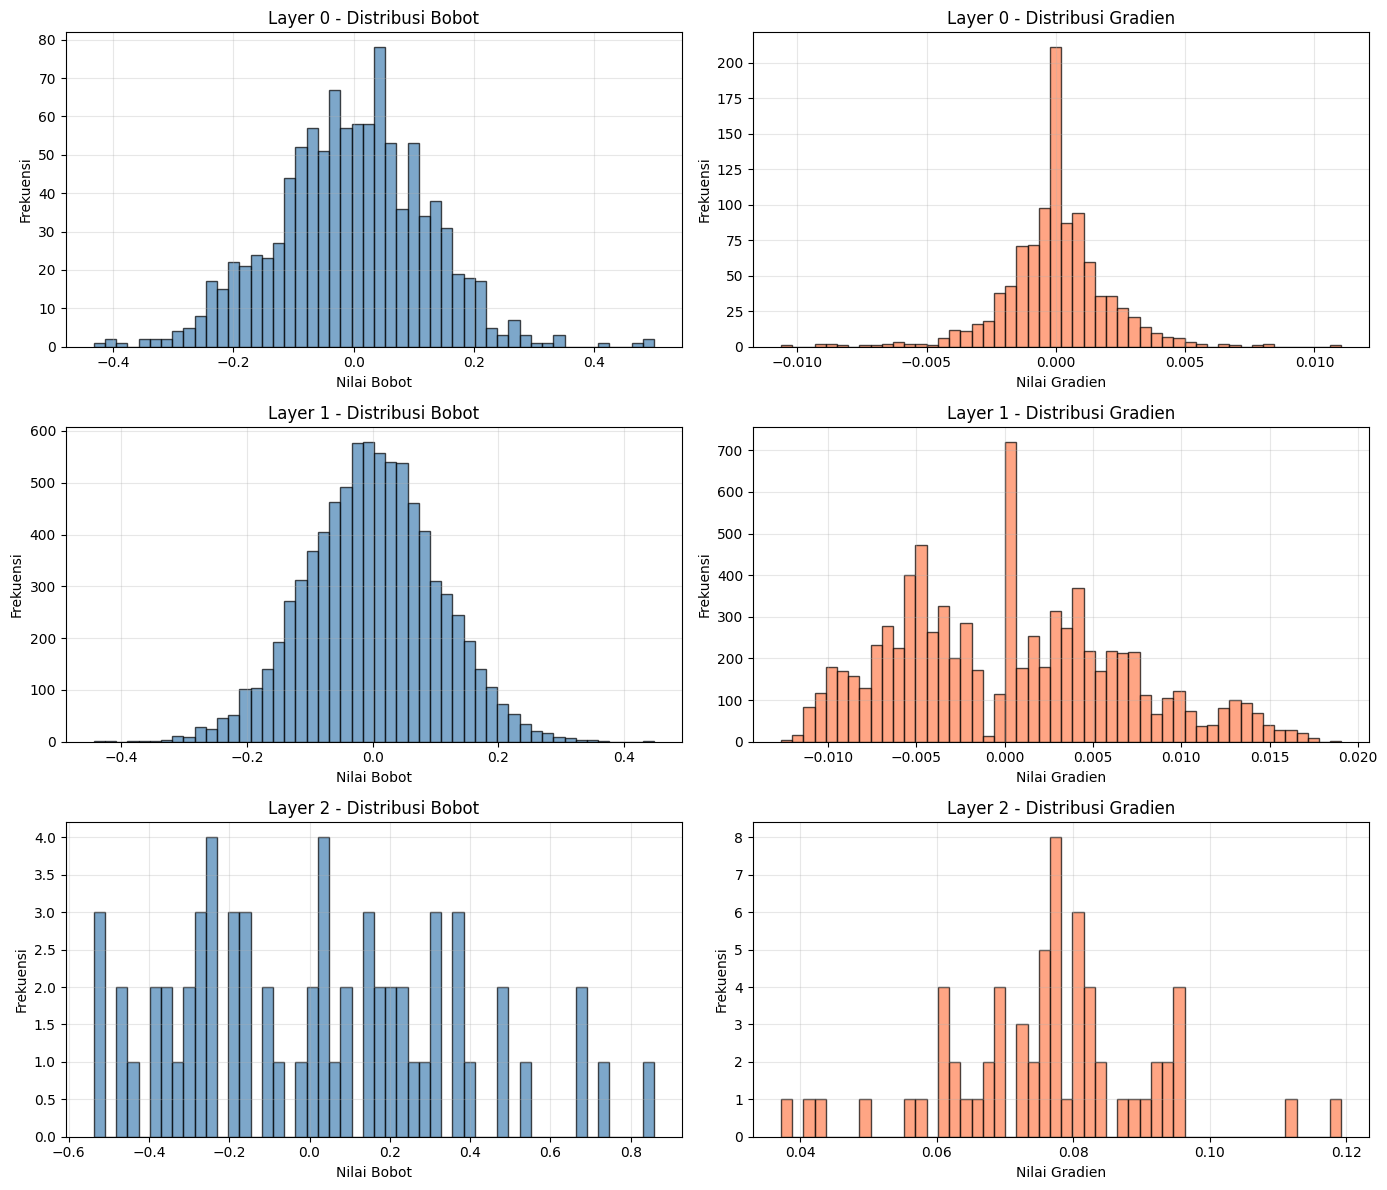


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Tanh
Test Accuracy: 0.7625

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.003045 | Std: 0.113432
  Min: -1.235016 | Max: 0.430650
  Median: 0.000293

Layer 1:
  Shape: (128, 64)
  Mean: -0.000902 | Std: 0.101865
  Min: -0.459782 | Max: 0.395706
  Median: -0.000748

Layer 2:
  Shape: (64, 1)
  Mean: -0.002533 | Std: 0.208769
  Min: -0.394377 | Max: 0.642396
  Median: 0.006242

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001194 | Std: 0.017459
  Min: -0.150718 | Max: 0.104066
  Median: -0.000718
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

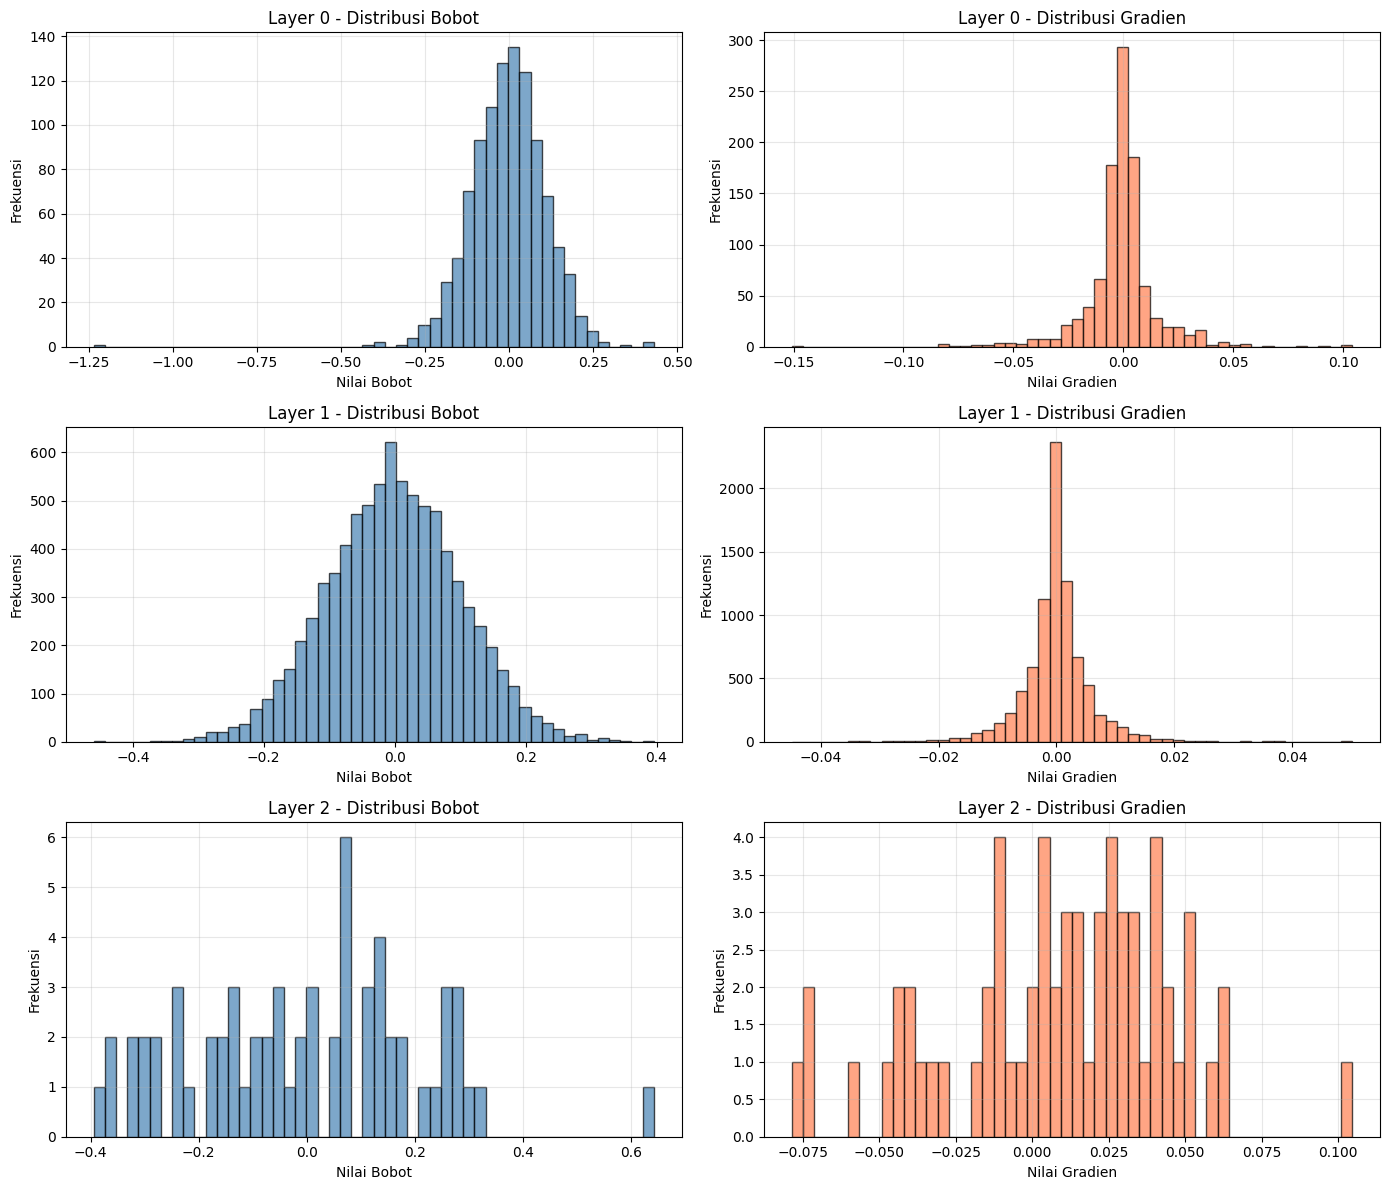

In [12]:
analyze_results_distributions(
    activation_results,
    result_group_name='Activation',
)

### 4.1.3 Learning Rate

In [13]:
learning_rates = {
    'LR_0.001': 0.001,
    'LR_0.01': 0.01,
    'LR_0.1': 0.1,
}

BASE_LR_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

lr_results = run_learning_rate_experiments(
    learning_rates=learning_rates,
    base_arch=BASE_LR_ARCH,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: LR_0.001 (lr=0.001)
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5073, Val Loss: 0.5033
Epoch 20/200, Train Loss: 0.4992, Val Loss: 0.4985
Epoch 30/200, Train Loss: 0.4942, Val Loss: 0.4962
Epoch 40/200, Train Loss: 0.4908, Val Loss: 0.4960
Epoch 50/200, Train Loss: 0.4901, Val Loss: 0.4954
Epoch 60/200, Train Loss: 0.4881, Val Loss: 0.4956
Epoch 70/200, Train Loss: 0.4869, Val Loss: 0.4969
Epoch 80/200, Train Loss: 0.4865, Val Loss: 0.4959
Epoch 90/200, Train Loss: 0.4852, Val Loss: 0.4961
Epoch 100/200, Train Loss: 0.4838, Val Loss: 0.4977
Epoch 110/200, Train Loss: 0.4830, Val Loss: 0.4983
Epoch 120/200, Train Loss: 0.4831, Val Loss: 0.4971
Epoch 130/200, Train Loss: 0.4805, Val Loss: 0.4975
Epoch 140/200, Train Loss: 0.4799, V

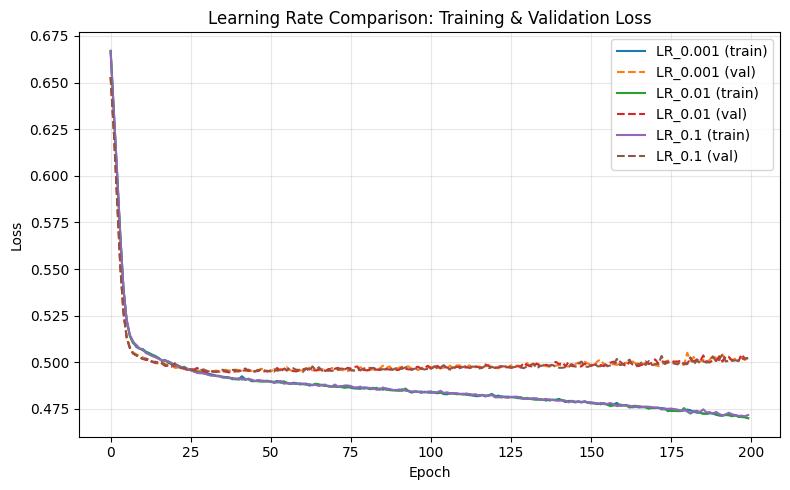

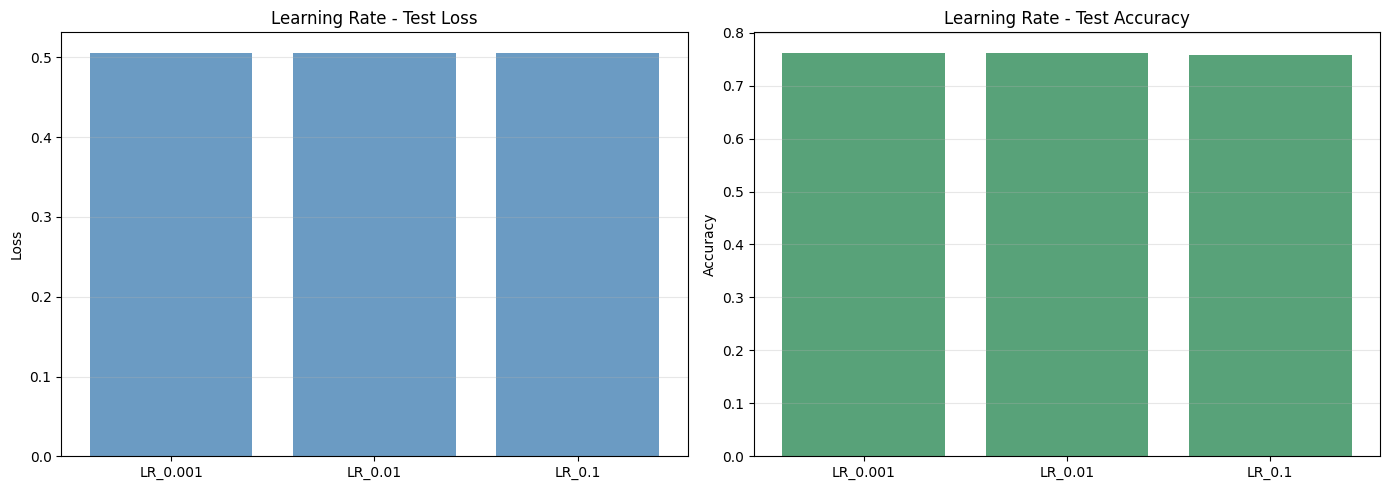

In [14]:
plot_train_val_curves(
    lr_results,
    title='Learning Rate Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    lr_results,
    title_prefix='Learning Rate',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.001
Test Accuracy: 0.7615

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001439 | Std: 0.125588
  Min: -0.400889 | Max: 0.553375
  Median: 0.002923

Layer 1:
  Shape: (128, 64)
  Mean: 0.001489 | Std: 0.103988
  Min: -0.439488 | Max: 0.413467
  Median: 0.001878

Layer 2:
  Shape: (64, 1)
  Mean: 0.033094 | Std: 0.310984
  Min: -0.615070 | Max: 0.706006
  Median: 0.036078

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000522 | Std: 0.022634
  Min: -0.135012 | Max: 0.112108
  Median: 0.000404
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

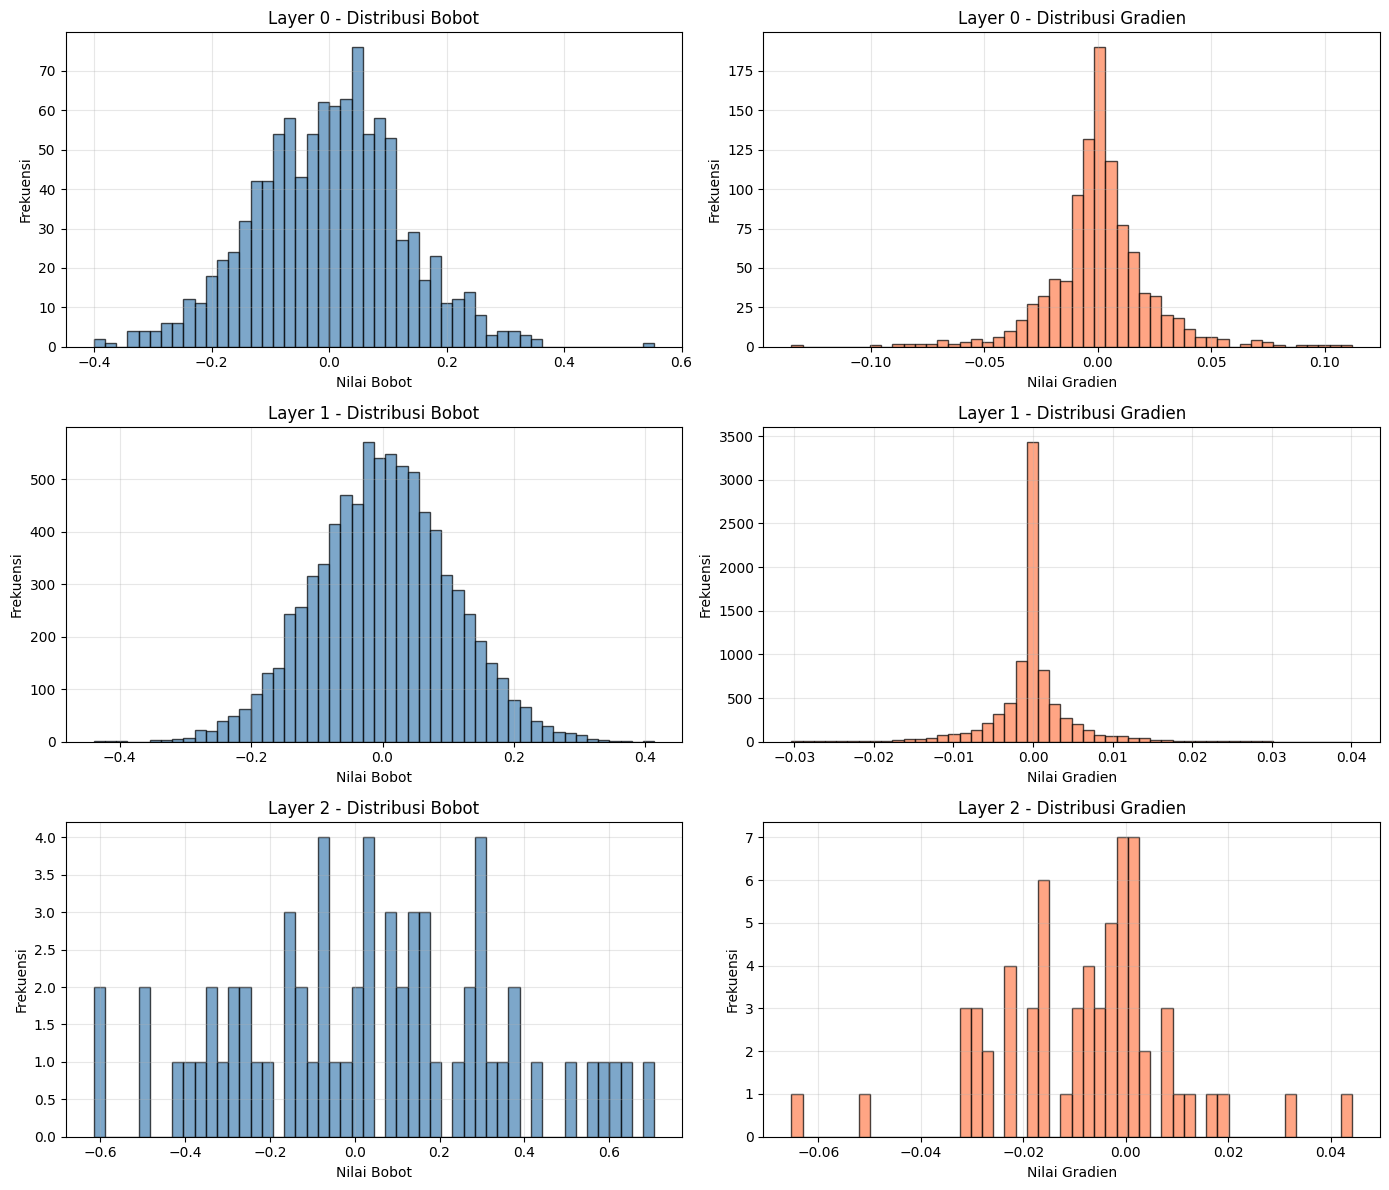


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.01
Test Accuracy: 0.7625

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001652 | Std: 0.125332
  Min: -0.395098 | Max: 0.562147
  Median: 0.001535

Layer 1:
  Shape: (128, 64)
  Mean: 0.001634 | Std: 0.103951
  Min: -0.439533 | Max: 0.417616
  Median: 0.001573

Layer 2:
  Shape: (64, 1)
  Mean: 0.031948 | Std: 0.309968
  Min: -0.612798 | Max: 0.711836
  Median: 0.034970

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000686 | Std: 0.020415
  Min: -0.082721 | Max: 0.115327
  Median: -0.000143
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

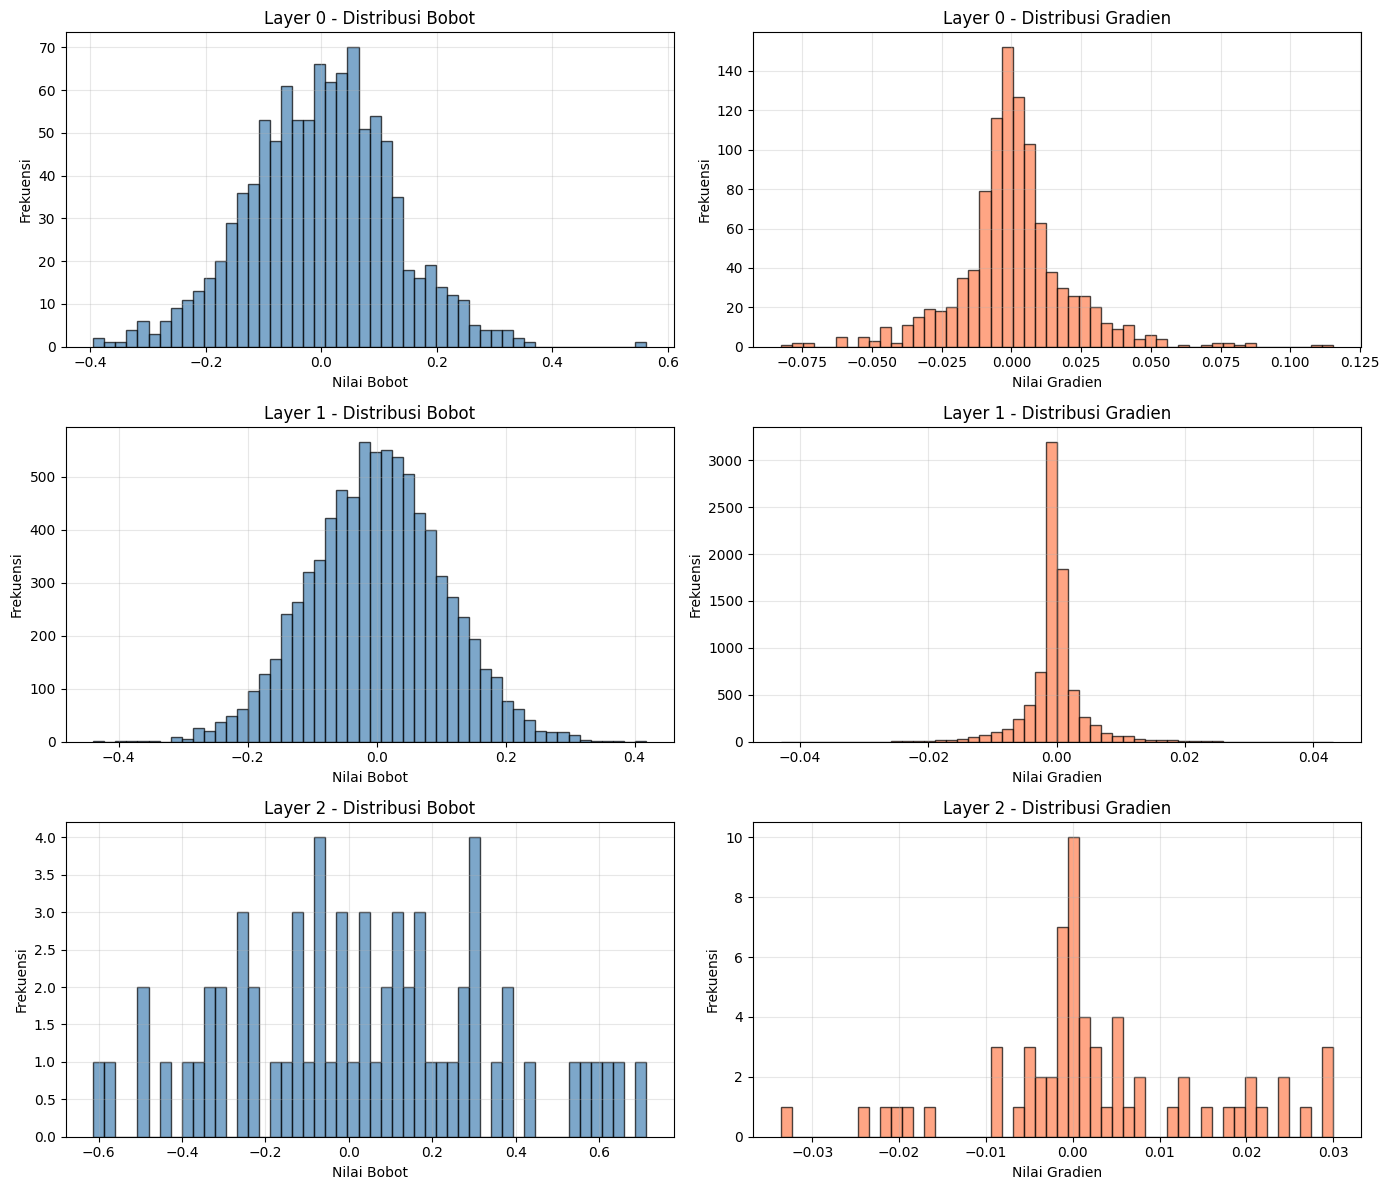


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.1
Test Accuracy: 0.7585

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002022 | Std: 0.125058
  Min: -0.396368 | Max: 0.546082
  Median: 0.001818

Layer 1:
  Shape: (128, 64)
  Mean: 0.001509 | Std: 0.103910
  Min: -0.438287 | Max: 0.415632
  Median: 0.001414

Layer 2:
  Shape: (64, 1)
  Mean: 0.032276 | Std: 0.308036
  Min: -0.619079 | Max: 0.690582
  Median: 0.035160

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000514 | Std: 0.039933
  Min: -0.164511 | Max: 0.198646
  Median: -0.000438
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

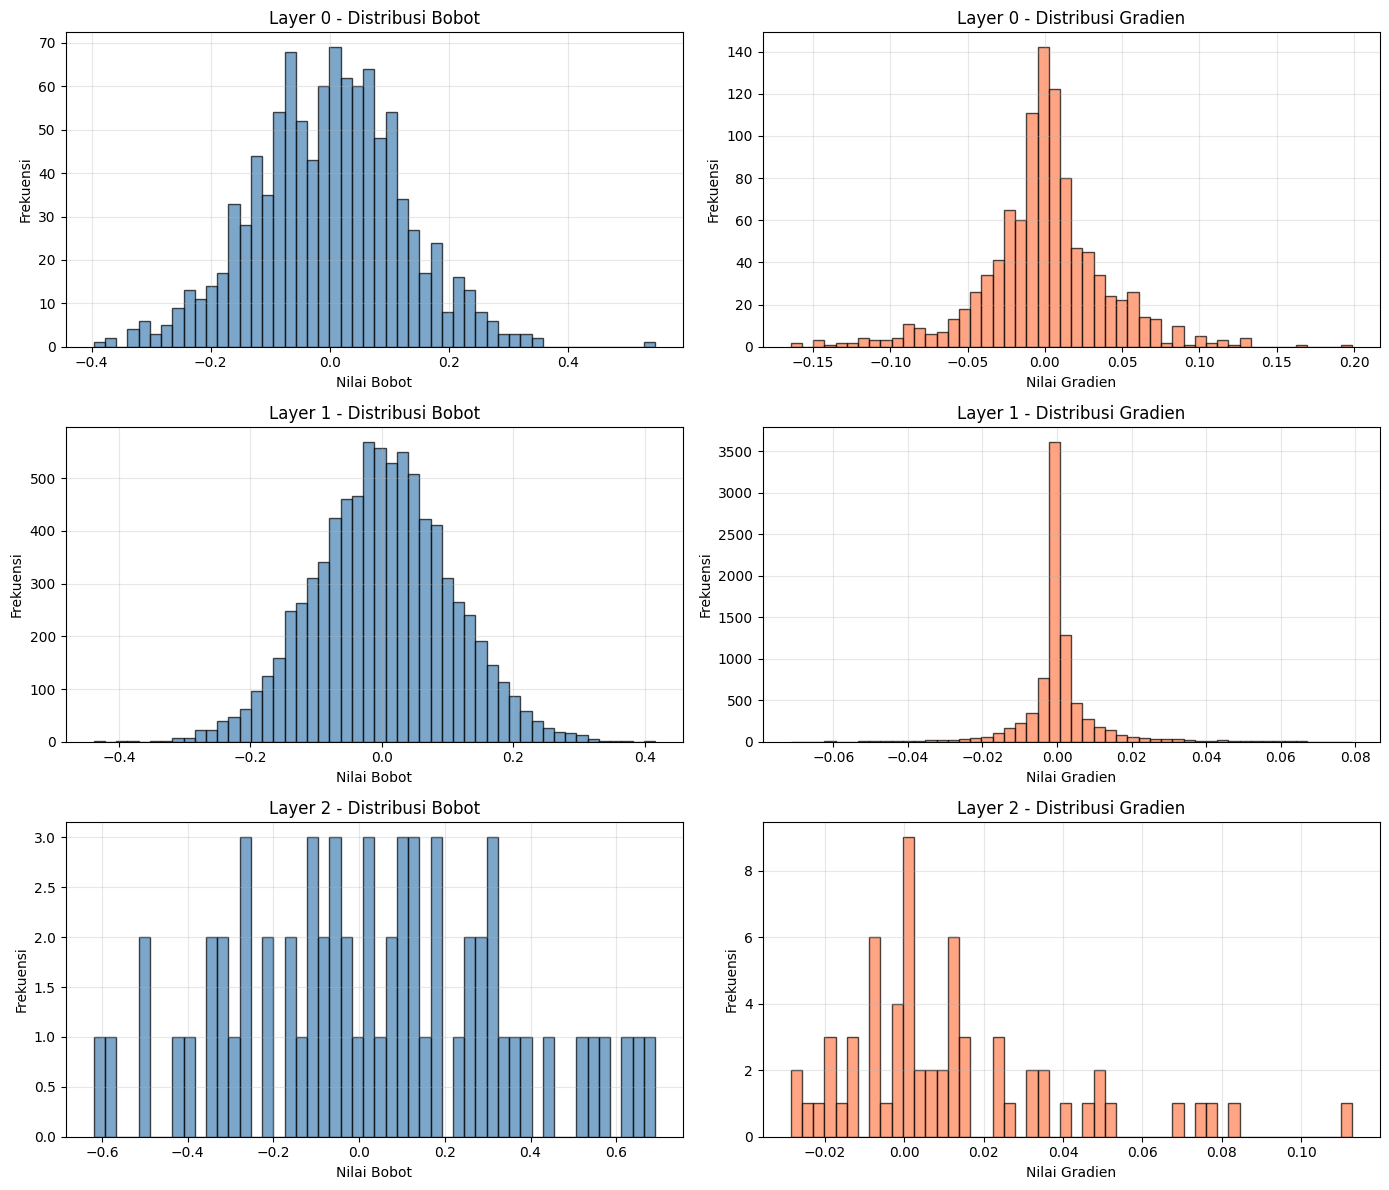

In [15]:
analyze_results_distributions(
    lr_results,
    result_group_name='Learning Rate',
)

### 4.1.4 Pengaruh Inisialisasi Bobot

Memulai Eksperimen Inisialisasi Bobot...

Menguji Inisialisasi: ZERO

Running: zero
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

zero - Test Loss: 0.6678, Accuracy: 0.6125

Menguji Inisialisasi: RANDOM_UNIFORM

Running: random_uniform
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_uniform - Test Loss: 0.5072, Accuracy: 0.7530

Menguji Inisialisasi: RANDOM_NORMAL

Running: random_normal
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_normal - Test Loss: 0.5132, Accuracy: 0.7425


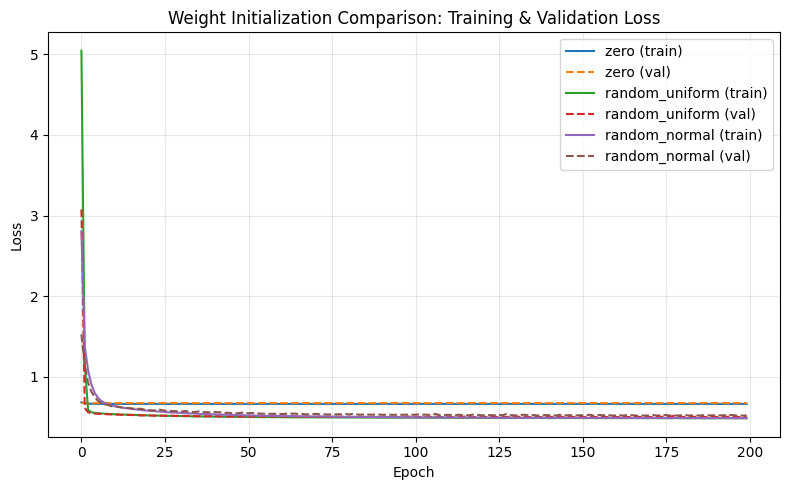

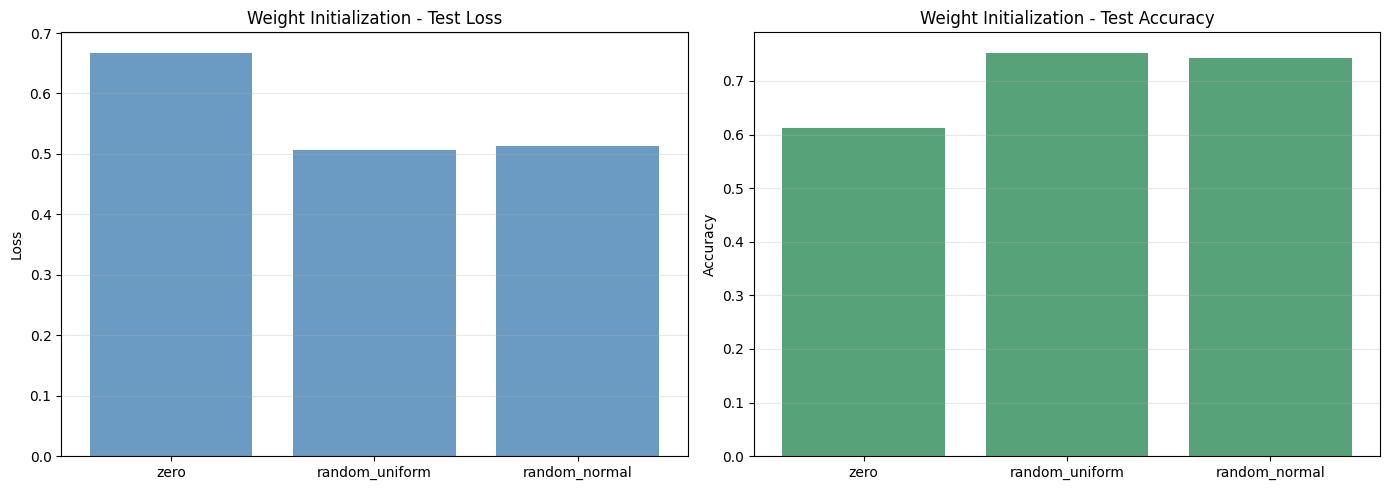

In [16]:
print("Memulai Eksperimen Inisialisasi Bobot...")

init_methods = ['zero', 'random_uniform', 'random_normal']
init_results = {}

last_act = 'softmax' if TASK == 'multiclass' else 'sigmoid'
arch_for_init = [
    {'n_in': n_features, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': last_act},
]

for method in init_methods:
    print(f"\n============================================================")
    print(f"Menguji Inisialisasi: {method.upper()}")
    print(f"============================================================")
    
    temp_exp = {method: arch_for_init}
    init_dict = {'init_method': method} 
    
    res = run_architecture_experiments(
        experiments=temp_exp,
        task=TASK,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        init=init_dict,        
        lr=0.01, 
        regularization='none',
        epochs=200,
        batch_size=32,
        verbose=0,             
    )
    init_results[method] = res[method]


plot_train_val_curves(init_results, title='Weight Initialization Comparison: Training & Validation Loss')

plot_prediction_bars(init_results, title_prefix='Weight Initialization')

## 4.2 Pengaruh Regularisasi


Running: Reg_None
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5075, Val Loss: 0.5032
Epoch 20/200, Train Loss: 0.4991, Val Loss: 0.4980
Epoch 30/200, Train Loss: 0.4942, Val Loss: 0.4955
Epoch 40/200, Train Loss: 0.4915, Val Loss: 0.4959
Epoch 50/200, Train Loss: 0.4899, Val Loss: 0.4963
Epoch 60/200, Train Loss: 0.4884, Val Loss: 0.4949
Epoch 70/200, Train Loss: 0.4869, Val Loss: 0.4956
Epoch 80/200, Train Loss: 0.4870, Val Loss: 0.4958
Epoch 90/200, Train Loss: 0.4850, Val Loss: 0.4955
Epoch 100/200, Train Loss: 0.4839, Val Loss: 0.4968
Epoch 110/200, Train Loss: 0.4827, Val Loss: 0.4971
Epoch 120/200, Train Loss: 0.4820, Val Loss: 0.4967
Epoch 130/200, Train Loss: 0.4808, Val Loss: 0.4968
Epoch 140/200, Train Loss: 0.4797, Val Loss: 0.

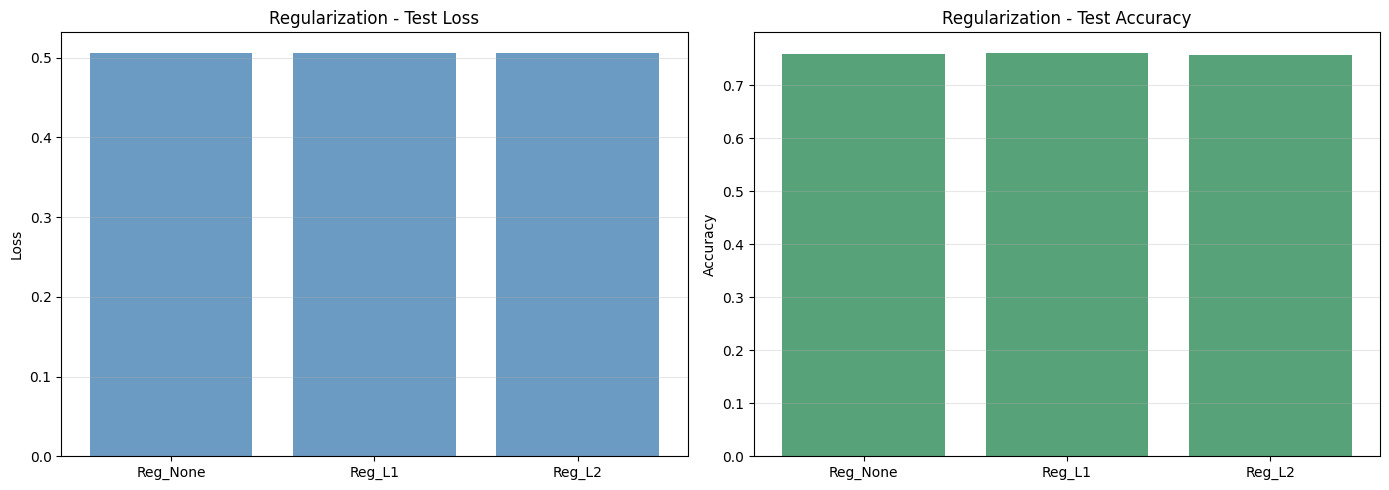

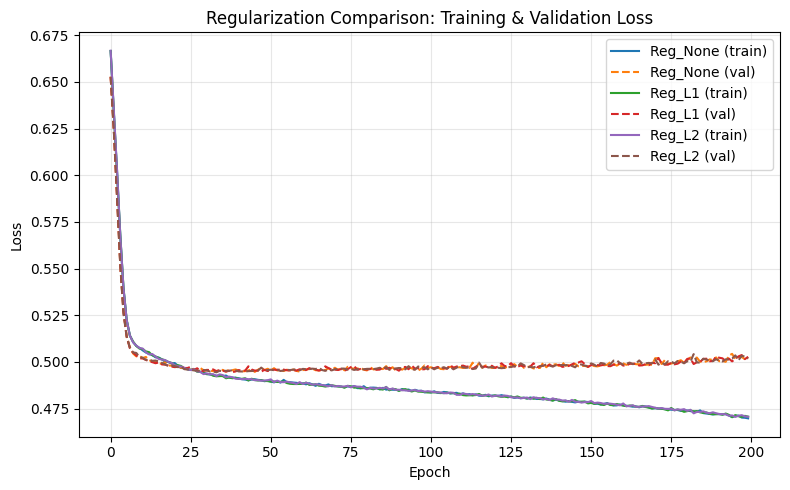


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_None
Test Accuracy: 0.7595

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001515 | Std: 0.125247
  Min: -0.392582 | Max: 0.550099
  Median: 0.003579

Layer 1:
  Shape: (128, 64)
  Mean: 0.001535 | Std: 0.103952
  Min: -0.439773 | Max: 0.417816
  Median: 0.001755

Layer 2:
  Shape: (64, 1)
  Mean: 0.031907 | Std: 0.310076
  Min: -0.625144 | Max: 0.706590
  Median: 0.037322

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000215 | Std: 0.014276
  Min: -0.061025 | Max: 0.066706
  Median: 0.000009
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

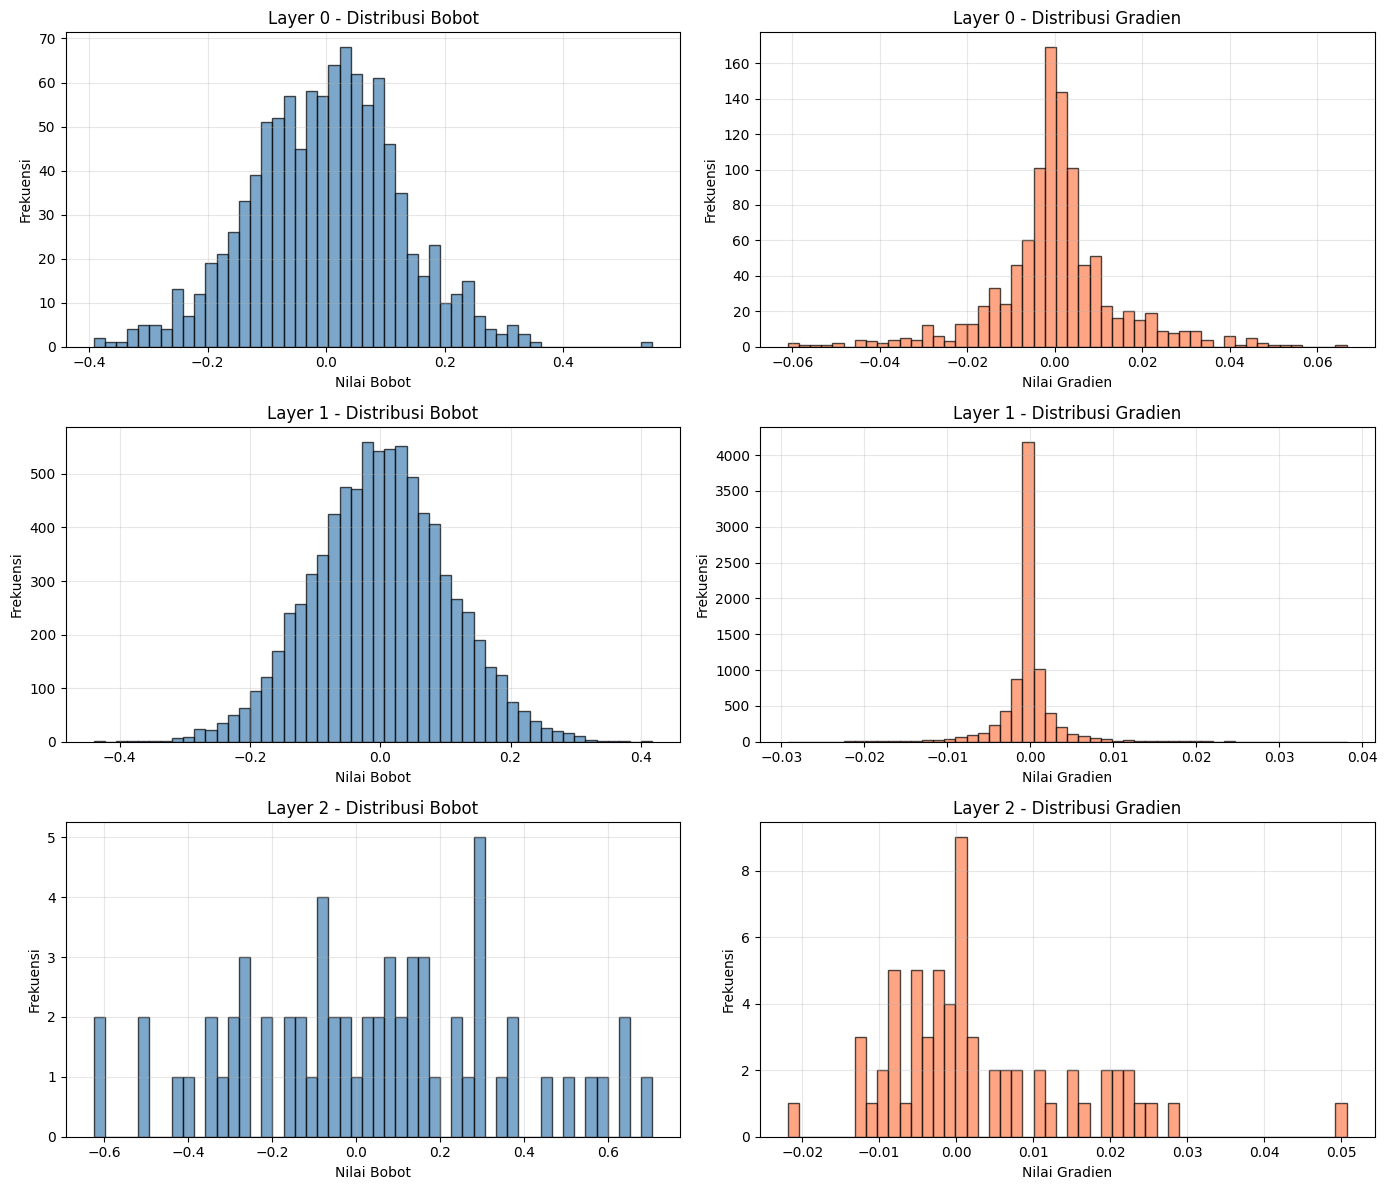


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L1
Test Accuracy: 0.7615

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001845 | Std: 0.125158
  Min: -0.395401 | Max: 0.551815
  Median: 0.002590

Layer 1:
  Shape: (128, 64)
  Mean: 0.001618 | Std: 0.103943
  Min: -0.438651 | Max: 0.415667
  Median: 0.001693

Layer 2:
  Shape: (64, 1)
  Mean: 0.031739 | Std: 0.309569
  Min: -0.624412 | Max: 0.704293
  Median: 0.030218

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000267 | Std: 0.026878
  Min: -0.116863 | Max: 0.114589
  Median: -0.000021
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

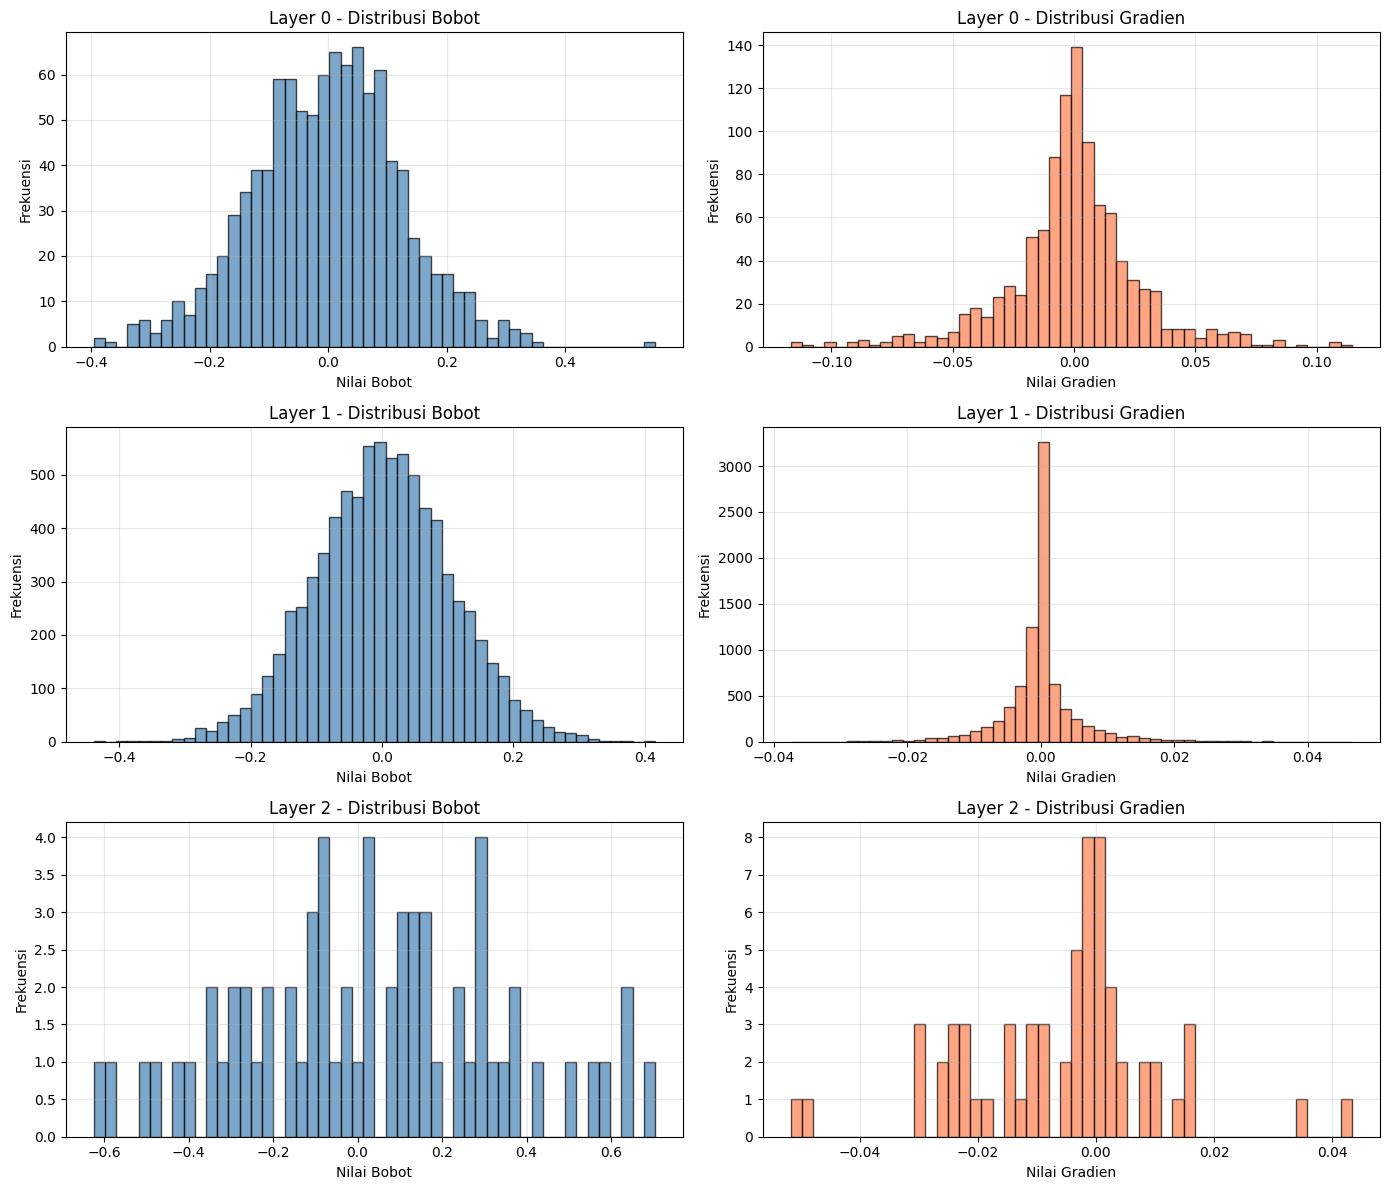


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L2
Test Accuracy: 0.7575

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001845 | Std: 0.125127
  Min: -0.392532 | Max: 0.548949
  Median: 0.001995

Layer 1:
  Shape: (128, 64)
  Mean: 0.001618 | Std: 0.103919
  Min: -0.439184 | Max: 0.417114
  Median: 0.001881

Layer 2:
  Shape: (64, 1)
  Mean: 0.031940 | Std: 0.308743
  Min: -0.623057 | Max: 0.702867
  Median: 0.030621

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000956 | Std: 0.019644
  Min: -0.089404 | Max: 0.106579
  Median: -0.000355
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

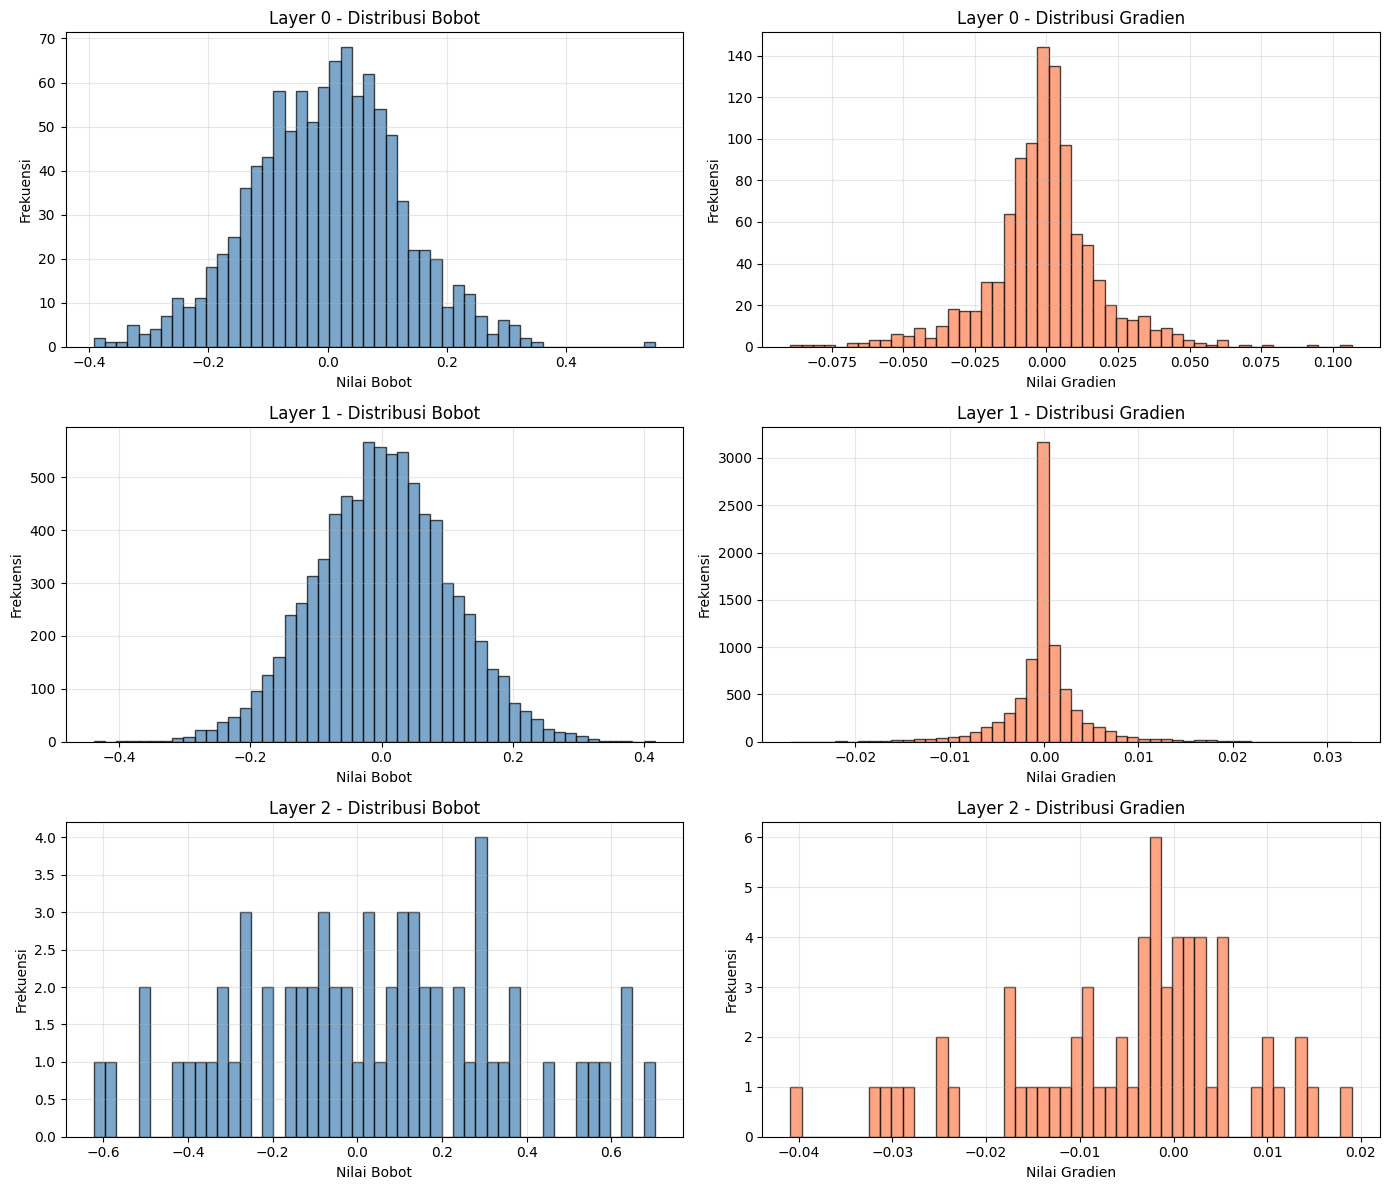

In [17]:
regularization_settings = {
    'Reg_None': {'regularization': 'none', 'lambda_': 0.0},
    'Reg_L1': {'regularization': 'l1', 'lambda_': 1e-4},
    'Reg_L2': {'regularization': 'l2', 'lambda_': 1e-4},
}

REG_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

regularization_results = {}

for exp_name, cfg in regularization_settings.items():
    one_exp = {exp_name: REG_ARCH}

    res = run_architecture_experiments(
        experiments=one_exp,
        task=TASK,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        init=INIT,
        lr=0.01,
        regularization=cfg['regularization'],
        lambda_=cfg['lambda_'],
        epochs=200,
        batch_size=32,
        verbose=20,
    )

    for k, v in res.items():
        v['regularization'] = cfg['regularization']
        v['lambda_'] = cfg['lambda_']

    regularization_results.update(res)

reg_summary = pd.DataFrame([
    {
        'experiment': name,
        'regularization': result['regularization'],
        'lambda': result['lambda_'],
        'test_loss': result['test_loss'],
        'test_accuracy': result['test_accuracy'],
    }
    for name, result in regularization_results.items()
]).sort_values(by='test_accuracy', ascending=False)

print('\nRINGKASAN HASIL AKHIR PREDIKSI (REGULARISASI)')
print(reg_summary.to_string(index=False))

plot_prediction_bars(
    regularization_results,
    title_prefix='Regularization',
)

plot_train_val_curves(
    regularization_results,
    title='Regularization Comparison: Training & Validation Loss',
    zoom_start=50,
)

analyze_results_distributions(
    regularization_results,
    result_group_name='Regularization',
)

## 4.3 Uji Perbandingan

In [18]:
from sklearn.neural_network import MLPClassifier
import pandas as pd

# Hyperparameter
SHARED_HPARAMS = {
    'hidden_dims': (128, 64),
    'lr': 0.01,
    'batch_size': 32,
    'epochs': 200,
    'lambda_': 1e-4,
    'seed': 42,
}

# 1) Train FFNN from scratch
ffnn_arch = [
    {'n_in': n_features, 'n_out': SHARED_HPARAMS['hidden_dims'][0], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][0], 'n_out': SHARED_HPARAMS['hidden_dims'][1], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][1], 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

ffnn_result = run_architecture_experiments(
    experiments={'FFNN_Scratch': ffnn_arch},
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init={'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': SHARED_HPARAMS['seed']}},
    lr=SHARED_HPARAMS['lr'],
    regularization='l2',
    lambda_=SHARED_HPARAMS['lambda_'],
    epochs=SHARED_HPARAMS['epochs'],
    batch_size=SHARED_HPARAMS['batch_size'],
    verbose=20,
)['FFNN_Scratch']

ffnn_model = ffnn_result['model']
ffnn_prob = ffnn_model.predict(X_test)
if TASK == 'binary':
    y_true_cls = y_test.astype(int).ravel()
    y_pred_ffnn = (ffnn_prob >= 0.5).astype(int).ravel()
else:
    y_true_cls = np.argmax(y_test, axis=1)
    y_pred_ffnn = np.argmax(ffnn_prob, axis=1)

if TASK == 'binary':
    y_train_sklearn = y_train.ravel().astype(int)
else:
    y_train_sklearn = np.argmax(y_train, axis=1)

sk_mlp = MLPClassifier(
    hidden_layer_sizes=SHARED_HPARAMS['hidden_dims'],
    activation='relu',
    solver='sgd',
    alpha=SHARED_HPARAMS['lambda_'],
    learning_rate_init=SHARED_HPARAMS['lr'],
    batch_size=SHARED_HPARAMS['batch_size'],
    max_iter=SHARED_HPARAMS['epochs'],
    random_state=SHARED_HPARAMS['seed'],
)

sk_mlp.fit(X_train, y_train_sklearn)
y_pred_sklearn = sk_mlp.predict(X_test)

comparison_df = pd.DataFrame([
    {
        'Model': 'FFNN From Scratch',
        'Test Accuracy': np.mean(y_pred_ffnn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_ffnn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_ffnn != y_true_cls)),
    },
    {
        'Model': 'sklearn MLPClassifier',
        'Test Accuracy': np.mean(y_pred_sklearn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_sklearn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_sklearn != y_true_cls)),
    },
]).sort_values(by='Test Accuracy', ascending=False)

print('Perbandingan hasil akhir prediksi (test set):')
display(comparison_df)


Running: FFNN_Scratch
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5073, Val Loss: 0.5026
Epoch 20/200, Train Loss: 0.4993, Val Loss: 0.4981
Epoch 30/200, Train Loss: 0.4941, Val Loss: 0.4957
Epoch 40/200, Train Loss: 0.4915, Val Loss: 0.4948
Epoch 50/200, Train Loss: 0.4899, Val Loss: 0.4955
Epoch 60/200, Train Loss: 0.4884, Val Loss: 0.4974
Epoch 70/200, Train Loss: 0.4869, Val Loss: 0.4959
Epoch 80/200, Train Loss: 0.4863, Val Loss: 0.4963
Epoch 90/200, Train Loss: 0.4851, Val Loss: 0.4958
Epoch 100/200, Train Loss: 0.4848, Val Loss: 0.4972
Epoch 110/200, Train Loss: 0.4837, Val Loss: 0.4973
Epoch 120/200, Train Loss: 0.4815, Val Loss: 0.4968
Epoch 130/200, Train Loss: 0.4804, Val Loss: 0.4991
Epoch 140/200, Train Loss: 0.4798, Val Loss

,Model,Test Accuracy,Prediksi Benar,Prediksi Salah
0,FFNN From Scratch,0.7580,1516,484
1,sklearn MLPClassifier,0.6765,1353,647


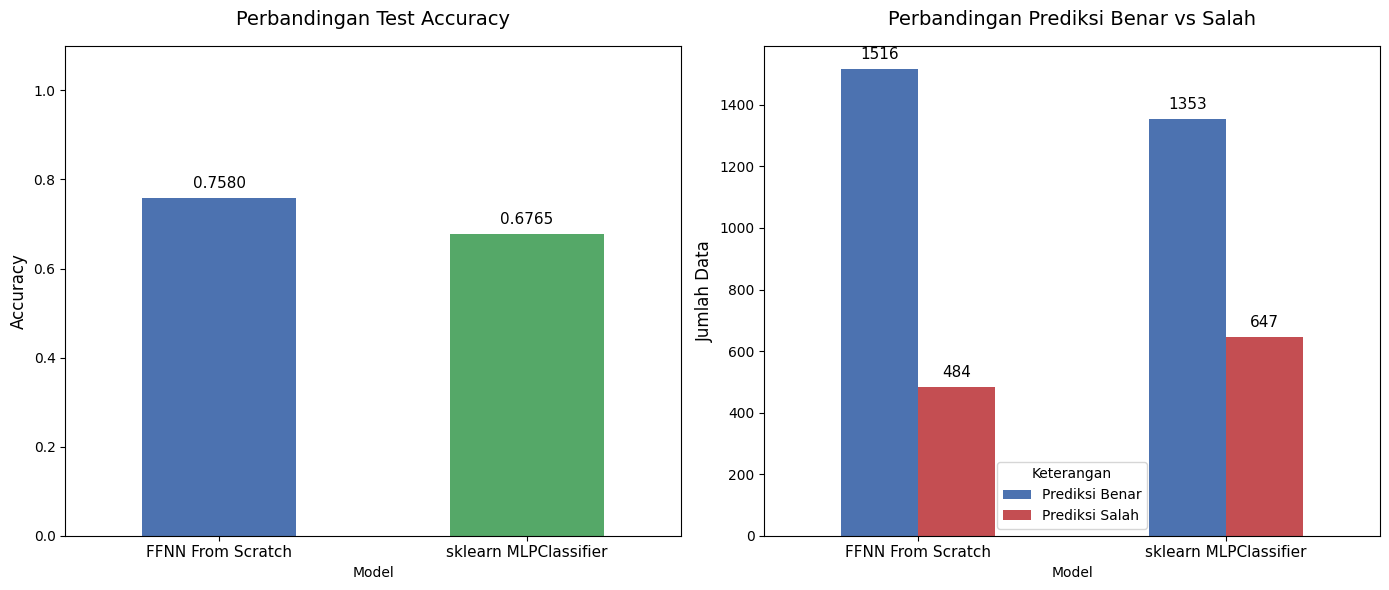

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

comparison_df.plot(
    x='Model', 
    y='Test Accuracy', 
    kind='bar', 
    ax=axes[0], 
    color=['#4C72B0', '#55A868'], 
    legend=False
)
axes[0].set_title('Perbandingan Test Accuracy', fontsize=14, pad=15)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim(0, 1.1) 
axes[0].tick_params(axis='x', rotation=0, labelsize=11)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

comparison_df.plot(
    x='Model', 
    y=['Prediksi Benar', 'Prediksi Salah'], 
    kind='bar', 
    ax=axes[1], 
    color=['#4C72B0', '#C44E52']
)
axes[1].set_title('Perbandingan Prediksi Benar vs Salah', fontsize=14, pad=15)
axes[1].set_ylabel('Jumlah Data', fontsize=12)
axes[1].tick_params(axis='x', rotation=0, labelsize=11)
axes[1].legend(title='Keterangan')

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f"{int(height)}", 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()